In [14]:
import json
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [15]:
records = []
base_dir = Path(".")
folders = ["1_1_test", "4_4_test", "8_8_test"]

for folder_name in folders:
    folder_path = base_dir / folder_name
    if not folder_path.exists():
        continue

    setup_match = re.match(r"(\d+_\d+)_test", folder_name)
    matrix_setup = setup_match.group(1) if setup_match else folder_name

    for json_file in folder_path.glob("*_test.json"):
        test_type = json_file.stem.replace("_test", "")

        with open(json_file, "r") as f:
            data = json.load(f)

        for code_version, vec_dict in data.items():
            for vec_size, runs in vec_dict.items():
                if not runs:
                    continue

                for run in runs:
                    records.append({
                        "matrix_number": matrix_setup,
                        "matrix_dim": test_type,
                        "version": code_version,
                        "vec": int(vec_size),
                        "kernel_ms": run.get("kernel_ms"),
                        "h2d_ms": run.get("h2d_ms"),
                        "d2h_ms": run.get("d2h_ms"),
                        "cpu_post_ms": run.get("cpu_post_ms"),
                        "effective_bw": run.get("effective_bw"),
                        "useful_threads": run.get("useful_threads")
                    })

df_testing = pd.DataFrame(records)
df_testing.sample(5)

,matrix_number,matrix_dim,version,vec,kernel_ms,h2d_ms,d2h_ms,cpu_post_ms,effective_bw,useful_threads
324,4_4,medium,2_gpu_naive,1,20.187,20.315,2.105,56.210,29.919,67108864
465,8_8,large,2_gpu_naive,8,303.959,329.095,75.929,841.141,31.793,134217728
554,8_8,medium,3_gpu_reduce,16,68.945,69.382,0.584,0.003,31.148,16777216
299,4_4,large,3_gpu_reduce,16,65.542,91.582,0.221,0.001,32.765,16777216
25,1_1,small,3_gpu_reduce,1,0.205,0.346,0.009,0.000,40.972,1048576


In [17]:
time_cols = ['kernel_ms', 'h2d_ms', 'd2h_ms', 'cpu_post_ms']

df_testing['total_ms'] = df_testing[time_cols].sum(axis=1)
df_testing['total_ms'] = df_testing['total_ms'].round(3)

df_testing.sample(5)

,matrix_number,matrix_dim,version,vec,kernel_ms,h2d_ms,d2h_ms,cpu_post_ms,effective_bw,useful_threads,total_ms
382,4_4,medium,4_gpu_reduce_batch,16,2.649,2.308,0.003,0.000,50.675,4194304,4.960
418,8_8,small,3_gpu_reduce,4,7.225,13.035,0.455,0.003,74.310,16777216,20.718
128,1_1,medium,1_cpu_baseline,1,2.773,NaN,NaN,NaN,NaN,4194304,2.773
553,8_8,medium,3_gpu_reduce,16,68.701,68.832,0.551,0.003,31.259,16777216,138.087
338,4_4,medium,2_gpu_naive,8,22.186,20.873,2.106,56.412,27.223,8388608,101.577


In [18]:
idx_best = df_testing.groupby(['matrix_number', 'matrix_dim', 'version', 'vec'])['total_ms'].idxmin()

df_best = df_testing.loc[idx_best].copy()

df_best['vec'] = df_best['vec'].astype(int)
df_best = df_best.sort_values(by=['version', 'vec']).reset_index(drop=True)

df_best.sample(5)

,matrix_number,matrix_dim,version,vec,kernel_ms,h2d_ms,d2h_ms,cpu_post_ms,effective_bw,useful_threads,total_ms
41,4_4,small,2_gpu_naive,8,2.127,3.652,0.509,15.538,70.984,2097152,21.826
107,8_8,small,4_gpu_reduce_batch,1,13.032,0.982,0.003,0.000,10.299,67108864,14.017
70,8_8,medium,3_gpu_reduce,2,63.702,69.641,0.569,0.003,33.711,134217728,133.915
92,1_1,small,3_gpu_reduce,16,0.131,0.347,0.007,0.000,63.939,65536,0.485
86,4_4,small,3_gpu_reduce,8,1.977,3.522,0.118,0.018,67.903,2097152,5.635


In [19]:
cpu_mask = df_best['version'] == '1_cpu_baseline'

cpu_total_baseline  = df_best[cpu_mask].groupby(['matrix_number', 'matrix_dim'])['total_ms'].min()

dim_index = df_best.set_index(['matrix_number', 'matrix_dim']).index
df_best['cpu_total_baseline_ms']  = dim_index.map(cpu_total_baseline)

df_best['speedup_ker'] = (df_best['cpu_total_baseline_ms'] / df_best['kernel_ms']).round(3)
df_best['speedup_e2e'] = (df_best['cpu_total_baseline_ms'] / df_best['total_ms']).round(3)

df_best.sample(5)

,matrix_number,matrix_dim,version,vec,kernel_ms,h2d_ms,d2h_ms,cpu_post_ms,effective_bw,useful_threads,total_ms,cpu_total_baseline_ms,speedup_ker,speedup_e2e
51,8_8,large,2_gpu_naive,16,342.896,359.209,63.276,871.194,28.183,67108864,1636.575,417.725,1.218,0.255
87,8_8,large,3_gpu_reduce,8,259.940,333.943,0.766,0.003,33.046,134217728,594.652,417.725,1.607,0.702
12,4_4,large,2_gpu_naive,1,74.586,90.692,18.743,200.091,32.391,268435456,384.112,111.724,1.498,0.291
21,4_4,large,2_gpu_naive,2,75.627,92.526,19.064,204.013,31.945,134217728,391.230,111.724,1.477,0.286
122,4_4,small,4_gpu_reduce_batch,4,0.853,0.372,0.003,0.000,39.327,4194304,1.228,7.115,8.341,5.794


In [20]:
import matplotlib.pyplot as plt
import numpy as np


def plot_speedup(
    df, target_matrix_number="8_8", target_matrix_dim="2048x2048"
):
    mask = (df["matrix_number"] == target_matrix_number) & (
        df["matrix_dim"] == target_matrix_dim
    )
    df_filtered = df[mask].copy()

    if df_filtered.empty:
        print(
            f"Nessun dato trovato per matrix_number='{target_matrix_number}' e matrix_dim='{target_matrix_dim}'"
        )
        return

    df_filtered = df_filtered.sort_values(by=["version", "vec"]).reset_index(
        drop=True
    )

    labels = []
    for _, row in df_filtered.iterrows():
        if "cpu" in str(row["version"]).lower():
            labels.append("CPU")
        else:
            labels.append(f"{row['version']} v{row['vec']}")

    su_ker = df_filtered["speedup_ker"].to_numpy()
    su_e2e = df_filtered["speedup_e2e"].to_numpy()

    x = np.arange(len(labels))
    width = 0.38

    fig, ax = plt.subplots(figsize=(15, 6))

    rects1 = ax.bar(
        x - width / 2, su_ker, width, label="Speed-up Kernel", color="#1f77b4"
    )
    rects2 = ax.bar(
        x + width / 2,
        su_e2e,
        width,
        label="Speed-up End-to-End",
        color="#ff7f0e",
    )

    ax.set_ylabel("Speed-up (x)")
    ax.set_title(
        f"Confronto Speed-up (Kernel vs End-to-End) rispetto a CPU Baseline [{target_matrix_number}, {target_matrix_dim}]"
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax.legend(frameon=True)
    ax.grid(axis="y", linestyle=":", alpha=0.6)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if np.isnan(height):
                continue
            ax.annotate(
                f"{height:.1f}x",
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()

In [29]:
def plot_time_breakdown(
    df, target_matrix_number="8_8", target_matrix_dim="large"
):
    mask = (df["matrix_number"] == target_matrix_number) & (
        df["matrix_dim"] == target_matrix_dim
    )
    df_filtered = df[mask].copy()

    if df_filtered.empty:
        print(
            f"Nessun dato trovato per matrix_number='{target_matrix_number}' e matrix_dim='{target_matrix_dim}'"
        )
        return

    df_filtered = df_filtered.sort_values(by=["version", "vec"]).reset_index(
        drop=True
    )

    labels = []
    for _, row in df_filtered.iterrows():
        if "cpu" in str(row["version"]).lower():
            labels.append("CPU Baseline")
        else:
            labels.append(f"{row['version']} (v{row['vec']})")

    h2d = df_filtered["h2d_ms"].fillna(0.0).to_numpy()
    kernel = df_filtered["kernel_ms"].fillna(0.0).to_numpy()
    d2h = df_filtered["d2h_ms"].fillna(0.0).to_numpy()
    cpu_post = df_filtered["cpu_post_ms"].fillna(0.0).to_numpy()

    if "total_ms" in df_filtered.columns:
        cpu_mask = df_filtered["version"].str.contains("cpu", case=False, na=False)
        kernel[cpu_mask & (kernel == 0.0)] = df_filtered.loc[
            cpu_mask & (kernel == 0.0), "total_ms"
        ].to_numpy()

    x = np.arange(len(labels))
    width = 0.55

    fig, ax = plt.subplots(figsize=(15, 6))

    p_cpu = ax.bar(
        x,
        cpu_post,
        width,
        label="CPU Post-Processing",
        color="#e74c3c",
    )
    p_d2h = ax.bar(
        x,
        d2h,
        width,
        bottom=cpu_post,
        label="Device-to-Host (D2H)",
        color="#e67e22",
    )
    p_ker = ax.bar(
        x,
        kernel,
        width,
        bottom=cpu_post + d2h,
        label="Kernel Execution",
        color="#2ecc71",
    )
    p_h2d = ax.bar(
        x,
        h2d,
        width,
        bottom=cpu_post + d2h + kernel,
        label="Host-to-Device (H2D)",
        color="#3498db",
    )

    total_time = cpu_post + d2h + kernel + h2d

    for idx, total in enumerate(total_time):
        if total > 0:
            ax.annotate(
                f"{total:.2f} ms",
                xy=(x[idx], total),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold",
            )

    ax.set_ylabel("Tempo di esecuzione (ms)")
    ax.set_title(
        f"Breakdown dei Tempi di Esecuzione per Versione [{target_matrix_number}, {target_matrix_dim}]"
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)

    handles, legend_labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[::-1],
        legend_labels[::-1],
        frameon=True,
        loc="upper right",
    )

    ax.grid(axis="y", linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

In [38]:
import matplotlib.pyplot as plt
import numpy as np


def plot_gpu_bandwidth(
    df,
    target_matrix_number="8_8",
    target_matrix_dim="large",
    peak_bandwidth_gbs=None,
):
    """X: Versione GPU (v1, v2, v3 con vettorizzazione)

    Y: Effective Bandwidth (GB/s)
    """
    # 1. Filtro configurazione ed esclusione CPU
    mask = (
        (df["matrix_number"] == target_matrix_number)
        & (df["matrix_dim"] == target_matrix_dim)
        & (~df["version"].str.contains("cpu", case=False, na=False))
    )
    df_filtered = df[mask].copy()

    if df_filtered.empty:
        print(
            f"Nessun dato GPU trovato per matrix_number='{target_matrix_number}' e matrix_dim='{target_matrix_dim}'"
        )
        return

    # 2. Ordinamento per versione e fattore di vettorizzazione
    df_filtered = df_filtered.sort_values(by=["version", "vec"]).reset_index(
        drop=True
    )

    labels = [
        f"{row['version']}\n(v{row['vec']})"
        for _, row in df_filtered.iterrows()
    ]
    bw_vals = df_filtered["effective_bw"].to_numpy()

    x = np.arange(len(labels))
    width = 0.55

    fig, ax = plt.subplots(figsize=(14, 6))

    colors = []
    for ver in df_filtered["version"]:
        if "naive" in ver.lower():
            colors.append("#e74c3c")
        elif "batch" in ver.lower():
            colors.append("#2ecc71")
        else:
            colors.append("#3498db")

    rects = ax.bar(
        x,
        bw_vals,
        width,
        color=colors,
        edgecolor="#2c3e50",
        linewidth=0.8,
        alpha=0.9,
    )

    # Linea teorica opzionale
    if peak_bandwidth_gbs is not None:
        ax.axhline(
            peak_bandwidth_gbs,
            color="#e67e22",
            linestyle="--",
            linewidth=1.5,
            label=f"Peak BW Teorica ({peak_bandwidth_gbs} GB/s)",
            alpha=0.85,
        )

    # 3. Annotazione compatta: solo valore GB/s, font ridotto e ruotato
    for rect in rects:
        height = rect.get_height()
        if np.isnan(height) or height == 0:
            continue

        ax.annotate(
            f"{height:.1f} GB/s",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=7.5,
            rotation=25,  # Inclinazione per non toccare le etichette adiacenti
        )

    ax.set_ylabel("Bandwidth Effettiva (GB/s)", fontsize=11)
    ax.set_title(
        f"Confronto Bandwidth Effettiva tra Versioni GPU [{target_matrix_number}, {target_matrix_dim}]",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=9)

    # Margine superiore aumentato per non tagliare il testo inclinato
    y_max = np.nanmax(bw_vals)
    if peak_bandwidth_gbs:
        y_max = max(y_max, peak_bandwidth_gbs)
    ax.set_ylim(0, y_max * 1.18)

    if peak_bandwidth_gbs is not None:
        ax.legend(frameon=True, loc="upper left")

    ax.grid(axis="y", linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

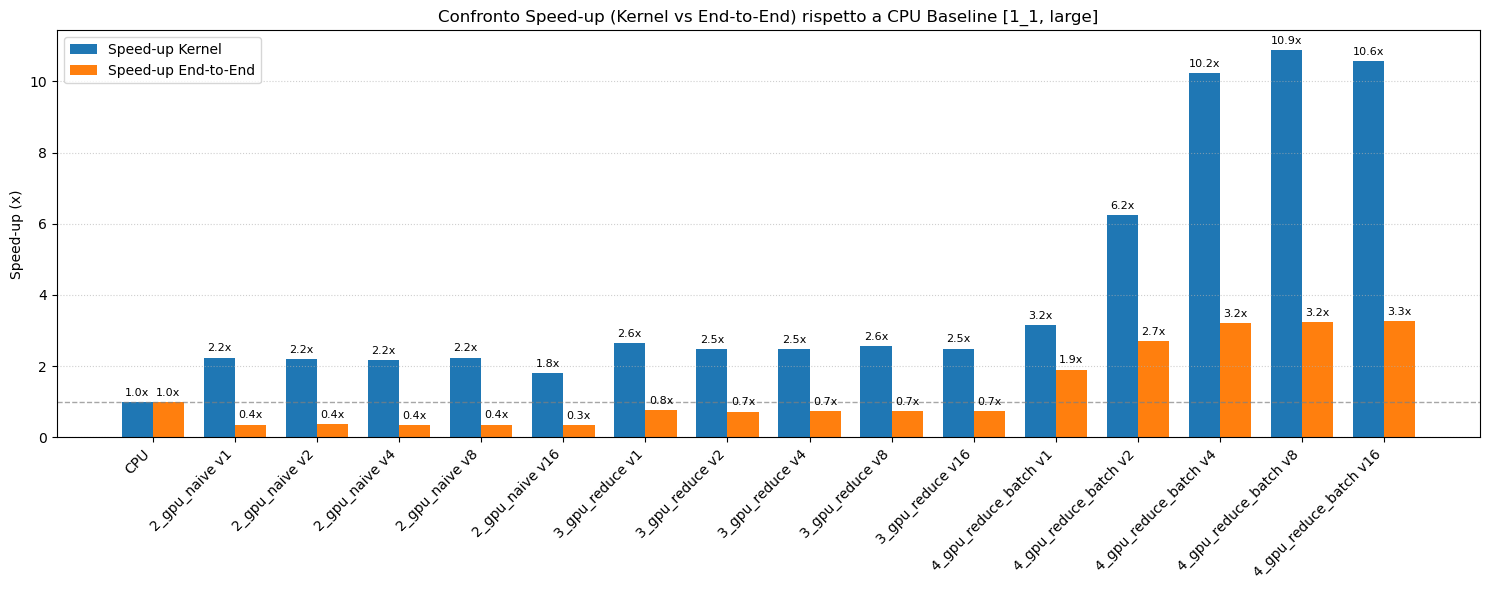

In [ ]:
plot_speedup(df_best, target_matrix_number="1_1", target_matrix_dim="large")

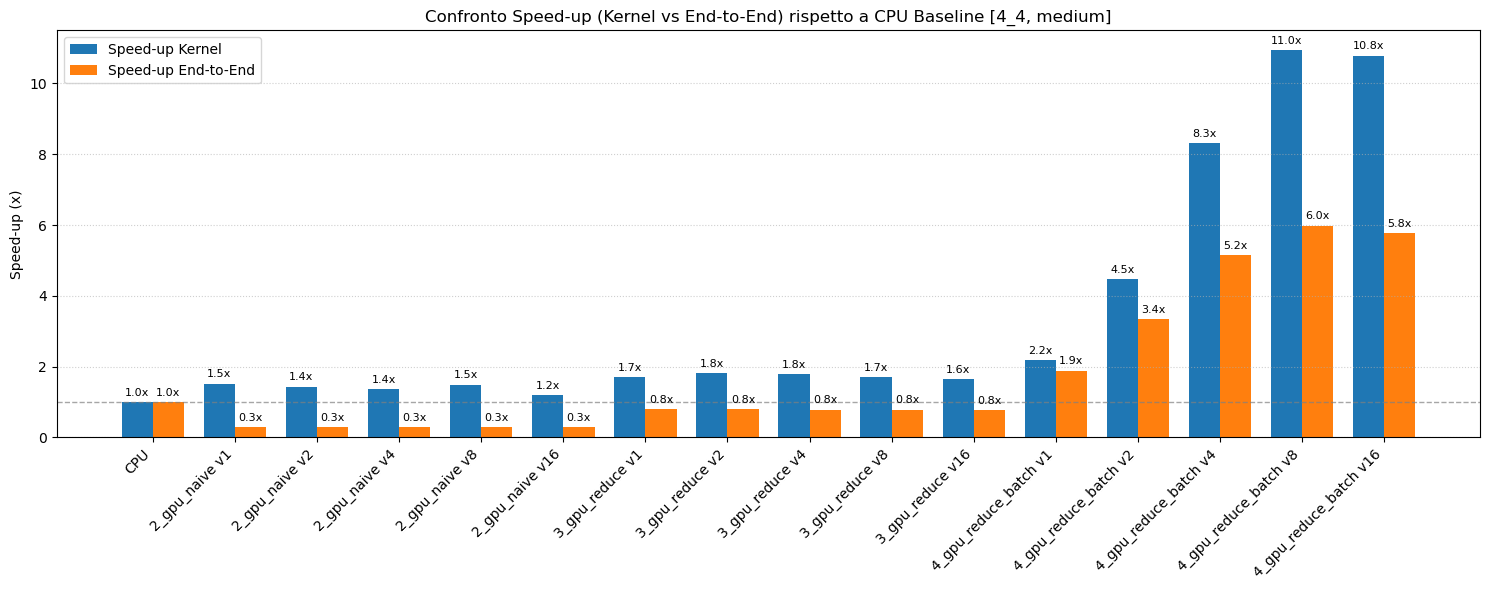

In [23]:
plot_speedup(df_best, target_matrix_number="4_4", target_matrix_dim="medium")


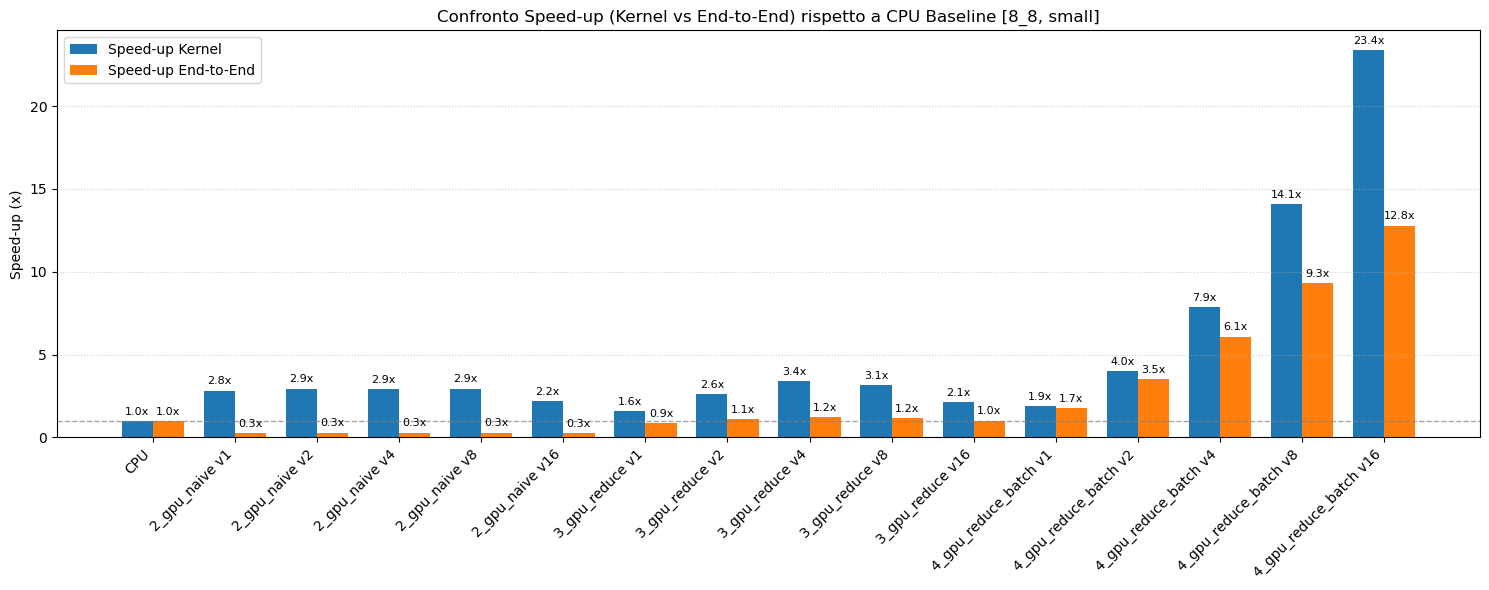

In [ ]:
plot_speedup(df_best, target_matrix_number="8_8", target_matrix_dim="small")

In [26]:
df_best.head()


,matrix_number,matrix_dim,version,vec,kernel_ms,h2d_ms,d2h_ms,cpu_post_ms,effective_bw,useful_threads,total_ms,cpu_total_baseline_ms,speedup_ker,speedup_e2e
0,1_1,large,1_cpu_baseline,1,10.137,NaN,NaN,NaN,NaN,16777216,10.137,10.137,1.0,1.0
1,1_1,medium,1_cpu_baseline,1,2.773,NaN,NaN,NaN,NaN,4194304,2.773,2.773,1.0,1.0
2,1_1,small,1_cpu_baseline,1,0.741,NaN,NaN,NaN,NaN,1048576,0.741,0.741,1.0,1.0
3,4_4,large,1_cpu_baseline,1,111.724,NaN,NaN,NaN,NaN,268435456,111.724,111.724,1.0,1.0
4,4_4,medium,1_cpu_baseline,1,28.578,NaN,NaN,NaN,NaN,67108864,28.578,28.578,1.0,1.0


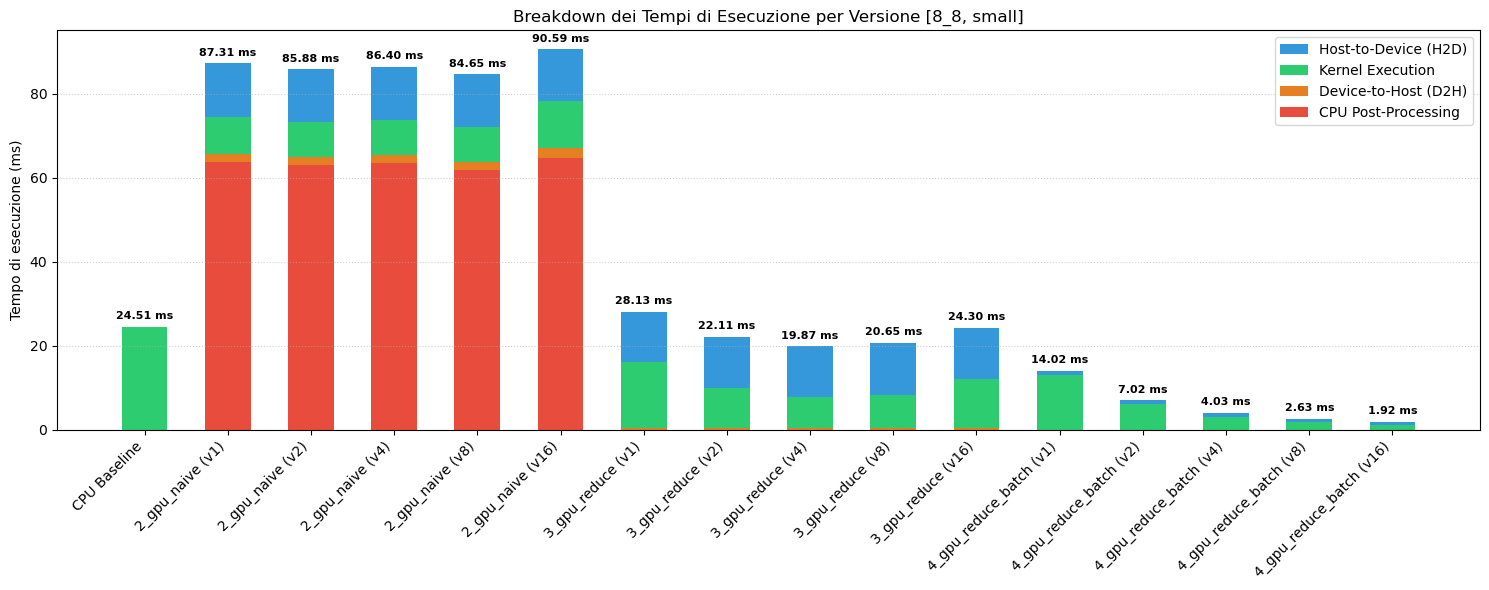

In [33]:
plot_time_breakdown(df_best, "8_8", "small")

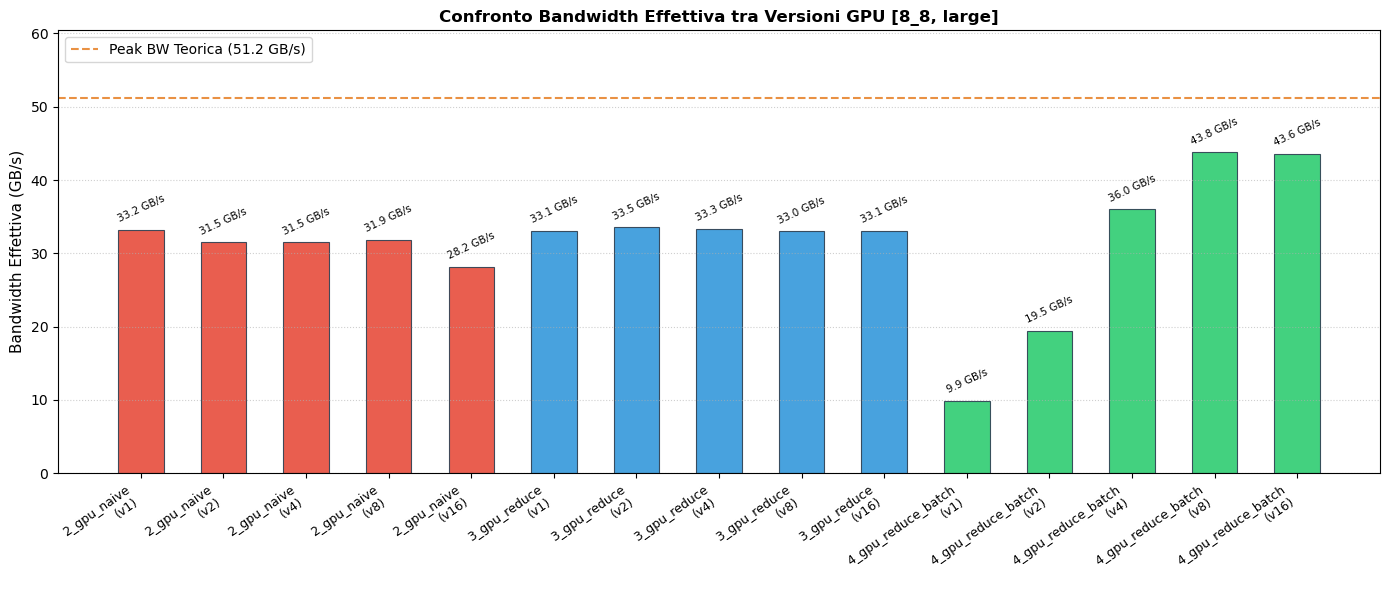

In [39]:
peak_memory_bw = 51.2

plot_gpu_bandwidth(df_best, "8_8", "large", peak_memory_bw)